In [44]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror{font-family:Consolas; font-size:15pt;}
div.output{font-size:12pt; font-weight:bold;}
div.input{font-family:Consolas; font-size:12pt;}
div.prompt{min-width:70px;}
div#toc-wrapper {padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# ※ naver open API를 활용하여 네이버지식인 "전주여행"과 "경주여행"을 검색(re 특수문자제거) -> 품사태깅 백업 -> 명사만 추출(mecab) -> 빈도분석(DataFrame) -> 빈도 시각화(워드클라우드, Text) -> Word2Vec 

# 1. naver open API를 활용하여 검색어 추출
- 검색어, no, title, link, description, title + ' ' + description(total_text)
- 데이터프레임으로 읽어들일수있도록

In [5]:
# pip install python-dotenv(환경변수를 쓰기 위한 라이브러리)
import os
os.getcwd() # 지금 현재 작업디렉토리

'C:\\ai_x\\source\\07_자연어처리'

In [2]:
%ls .env

 C 드라이브의 볼륨에는 이름이 없습니다.
 볼륨 일련 번호: 3664-591E

 C:\ai_x\source\07_자연어처리 디렉터리

2025-06-18  오후 05:47                58 .env
               1개 파일                  58 바이트
               0개 디렉터리  123,454,365,696 바이트 남음


In [8]:
from dotenv import load_dotenv
load_dotenv()

# print(os.getenv('Client_ID'))
# print(os.getenv('Client_Secret'))

True

In [9]:
# pip install python-decouple(주피터환경에서는 안 될 수도 있음)
from decouple import config
# print(config('Client_ID'))
# print(config('Client_Secret'))

In [33]:
# 패키지 import
import requests
import time
import os
import json # response 텍스트를 json 딕셔너리로
from html import unescape # description에 있는 &lt;(특수문자)을 <으로 변경, &gt;-> >
import pandas as pd
import numpy as np
import re

In [65]:
from dotenv import load_dotenv
import os
load_dotenv()
client_id = os.getenv('Client_ID')
client_secret = os.getenv('Client_Secret')
keywords = ['전주 여행', '경주 여행']
max_start = 5

In [66]:
def get_naver_in(keyword, start):
    url = f'https://openapi.naver.com/v1/search/kin.json?query={keyword}&display=100&start={start}'
    headers = {
        'X-Naver-Client-Id': client_id,
        'X-Naver-Client-Secret': client_secret
    }
    response = requests.get(url, headers=headers)
    # response.status_code 200 확인
    items = json.loads(response.text)['items']
    items_list = []
    for idx, item in enumerate(items):
        title = item.get('title').replace('<b>', '').replace('</b>', '')
        link = item.get('link')
        description = item.get('description').replace('<b>', '').replace('</b>', '')
        description = re.sub(r'[^a-zA-Z0-9가-힣]', ' ', description)
        description = re.sub('\s+', ' ', description)
        items_list.append({
            'keyword':keyword,
            'no':(start-1)*100+idx+1,
            'title':title,
            'link':link,
            'description':description,
            'total_text':title + ' ' + description})
    return items_list

In [67]:
items_list_total = []
for keyword in keywords:
    for start in range(1, max_start+1):
        print(start, keyword, '읽는 중')
        items_list_total.extend(get_naver_in(keyword, start))
        time.sleep(0.5)
df = pd.DataFrame(items_list_total)
df.to_csv('data/naver_kin.csv', index=False, sep='\t')

1 전주 여행 읽는 중
2 전주 여행 읽는 중
3 전주 여행 읽는 중
4 전주 여행 읽는 중
5 전주 여행 읽는 중
1 경주 여행 읽는 중
2 경주 여행 읽는 중
3 경주 여행 읽는 중
4 경주 여행 읽는 중
5 경주 여행 읽는 중


# 2. 품사태깅

In [68]:
import pandas as pd
df = pd.read_csv('data/naver_kin.csv', sep='\t')
# total_text = ''
# total_text+=[]
df.head(2)

,keyword,no,title,link,description,total_text
0,전주 여행,1,전주 가볼만한곳 추천 받아요,https://kin.naver.com/qna/detail.naver?d1id=9&...,추억의 7080 다양한체험 7080감성 추억여행 테마박물관 유익한시간 2 전북 전...,전주 가볼만한곳 추천 받아요 추억의 7080 다양한체험 7080감성 추억여행 테마...
1,전주 여행,2,전주여행갈려고하는데요!,https://kin.naver.com/qna/detail.naver?d1id=9&...,전주여행을 갈려고하는데요 아는사람과 갈려고하는데 호텔은 좋은가격에 정했고 음 2박3...,전주여행갈려고하는데요! 전주여행을 갈려고하는데요 아는사람과 갈려고하는데 호텔은 좋은...


In [71]:
df_list = df[['keyword', 'no', 'total_text']].values.tolist()
df_list[::500]

[['전주 여행',
  1,
  '전주 가볼만한곳 추천 받아요  추억의 7080 다양한체험 7080감성 추억여행 테마박물관 유익한시간 2 전북 전북투어패스 통합이용권 전북핫플 여러여행지 다양한체험 카페이용추가 전주여행필수 편안하고 즐거운 날이 되시길 바라겠습니다 감사합니다 '],
 ['경주 여행',
  1,
  '추석에 경주 여행 추석에 경주 여행 가는거 어떻게 생각하시나요 서울에서 버스를 타고 갈 경우 버스가 버스전용 차선에서 운행하나요 질문하신 추석 경주여행 관련 답변 드리도록 하겠습니다 첨성대 석굴암 불국사 등 유적지는 연중무휴로 ']]

In [72]:
from mecab import MeCab
mecab = MeCab()
stopwords = ['전주', '경주', '여행']
select_pos = ['NNG', 'NNP']

In [78]:
postagged_list = []
for i, row in enumerate(df_list):
    keyword = row[0]
    no = row[1]
    text = row[2]
    text_pos = mecab.pos(text)
    for token, pos in text_pos:
        if token not in stopwords and pos in select_pos and len(token)>1:
            postagged_list.append({'keyword':keyword,
                                   'no':no,
                                   'token':token,
                                   'pos':pos})
df_postagged = pd.DataFrame(postagged_list)
df_postagged

,keyword,no,token,pos
0,전주 여행,1,추천,NNG
1,전주 여행,1,추억,NNG
2,전주 여행,1,다양,NNG
3,전주 여행,1,체험,NNG
4,전주 여행,1,감성,NNG
...,...,...,...,...
14198,경주 여행,500,참고,NNG
14199,경주 여행,500,쭈니,NNP
14200,경주 여행,500,아빠,NNG
14201,경주 여행,500,블로그,NNG


In [79]:
df_postagged.to_csv('data/naver_kin_nouns.csv', index=False, sep='\t')

# 3.빈도분석(DataFrame) 후 백업

In [88]:
df_nouns = pd.read_csv('data/naver_kin_nouns.csv', sep='\t')
df_nouns.shape

(14203, 4)

In [89]:
df_nouns.iloc[::5000]

,keyword,no,token,pos
0,전주 여행,1,추천,NNG
5000,전주 여행,336,일정,NNG
10000,경주 여행,186,조사,NNG


In [90]:
df_nouns.groupby(['keyword', 'token'], as_index=False)['pos'].count()

,keyword,token,pos
0,경주 여행,가격,10
1,경주 여행,가능,24
2,경주 여행,가본적,5
3,경주 여행,가성,5
4,경주 여행,가시,5
...,...,...,...
884,전주 여행,환급,5
885,전주 여행,회관,5
886,전주 여행,휴가,5
887,전주 여행,휴무,5


In [107]:
df_token_grp = df_nouns.groupby('keyword')['token'].value_counts()
df_token_grp

keyword  token
경주 여행    코스       446
         추천       401
         계획       154
         숙소       139
         맛집       120
                 ... 
전주 여행    카페이        1
         통합         1
         패스         1
         편안         1
         필수         1
Name: token, Length: 889, dtype: int64

In [108]:
df_token_grp = df_token_grp.reset_index(name='token_count')
df_token_grp

,keyword,token,token_count
0,경주 여행,코스,446
1,경주 여행,추천,401
2,경주 여행,계획,154
3,경주 여행,숙소,139
4,경주 여행,맛집,120
...,...,...,...
884,전주 여행,카페이,1
885,전주 여행,통합,1
886,전주 여행,패스,1
887,전주 여행,편안,1


In [104]:
# 전주 여행과 경우 여행 여행 빈도 추출
a = pd.DataFrame([['단어1', 90],
                 ['단어2', 80]], columns=['단어', '전주빈도'])
b = pd.DataFrame([['단어1', 99],
                 ['단어2', 81]], columns=['단어', '경주빈도'])
display(a)
display(b)
ab = pd.merge(a, b,
              how='outer', # inner(공통), left, right, outer
              on='단어')   # 두 프레임을 어떤 열 기준으로 합칠지 지정
# pd.concat([a, b], axis=1)
ab.fillna(0, inplace=True)
ab['전주빈도'] = ab['전주빈도'].astype('int')
ab['경주빈도'] = ab['경주빈도'].astype(np.int16)
ab.info()

,단어,전주빈도
0,단어1,90
1,단어2,80


,단어,경주빈도
0,단어1,99
1,단어2,81


<class 'pandas.core.frame.DataFrame'>
Int64Index: 2 entries, 0 to 1
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   단어      2 non-null      object
 1   전주빈도    2 non-null      int32 
 2   경주빈도    2 non-null      int16 
dtypes: int16(1), int32(1), object(1)
memory usage: 44.0+ bytes


In [111]:
df_gj = df_token_grp.loc[df_token_grp['keyword']=='경주 여행', ['token','token_count']]
df_jj = df_token_grp.loc[df_token_grp['keyword']=='전주 여행', ['token','token_count']]
df_gj.shape, df_jj.shape

((463, 2), (426, 2))

In [112]:
df_gj.head()

,token,token_count
0,코스,446
1,추천,401
2,계획,154
3,숙소,139
4,맛집,120


In [113]:
df_jj.head()

,token,token_count
463,코스,481
464,여수,349
465,주달,304
466,추천,301
467,맛집,287


In [117]:
df_mrg = pd.merge(df_jj, df_gj, how='outer', on='token')
print(df_mrg.shape)
df_mrg.columns=['token', '전주빈도', '경주빈도']
df_mrg.fillna(0, inplace=True)
df_mrg['경주빈도'] = df_mrg['경주빈도'].astype('int')
df_mrg['전주빈도'] = df_mrg['전주빈도'].astype(np.int64) # 'int64'
df_mrg

(716, 3)


,token,전주빈도,경주빈도
0,코스,481,446
1,여수,349,0
2,주달,304,0
3,추천,301,401
4,맛집,287,120
...,...,...,...
711,권역,0,1
712,연중무휴,0,1
713,운행,0,1
714,전용,0,1


In [118]:
df_mrg.to_csv('data/naver_kin_nouns_count.csv', sep='\t')

# 4. 빈도 시각화(워드클라우드, Text)

In [30]:
df_nouns = pd.read_csv('data/naver_kin_nouns.csv', sep='\t')
df_nouns.iloc[::3000]

,keyword,no,token,pos
0,전주 여행,1,추천,NNG
3000,전주 여행,200,코스,NNG
6000,전주 여행,400,전문,NNG
9000,경주 여행,113,질문,NNG
12000,경주 여행,335,일정,NNG


In [31]:
df_gj_noun = df_nouns.loc[df_nouns['keyword']=='경주 여행','token'].to_list()
df_jj_noun = df_nouns.loc[df_nouns['keyword']=='전주 여행','token'].to_list()
print(df_gj_noun[:5])
print(df_jj_noun[:5])
gj = ' '.join(df_gj_noun)
jj = ' '.join(df_jj_noun)
print(gj[:10])
print(jj[:10])

['추석', '추석', '생각', '서울', '버스']
['추천', '추억', '다양', '체험', '감성']
추석 추석 생각 서
추천 추억 다양 체


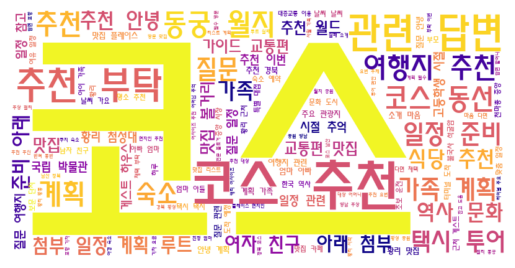

In [34]:
import numpy as np
from wordcloud import WordCloud
import matplotlib.pyplot as plt
불용어 = set(['여행'])
wordcloud = WordCloud(
    background_color='white',
    colormap='plasma',
    collocations=True, 
    max_words=200,
    max_font_size=200,
    scale=2,
    random_state=777,
    font_path='C:\Windows\Fonts\HMFMMUEX.TTC',
    stopwords=불용어,
    contour_color='blue',
    contour_width=1
).generate(gj)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

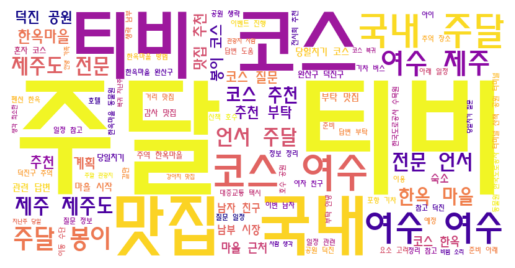

In [35]:
import numpy as np
불용어 = set(['여행'])
wordcloud = WordCloud(
    background_color='white',
    colormap='plasma',
    collocations=True,
    max_words=200,
    max_font_size=200,
    scale=2, 
    random_state=777,
    font_path='C:\Windows\Fonts\HMFMMUEX.TTC',
    stopwords=불용어,
    contour_color='blue',
    contour_width=1
).generate(jj)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

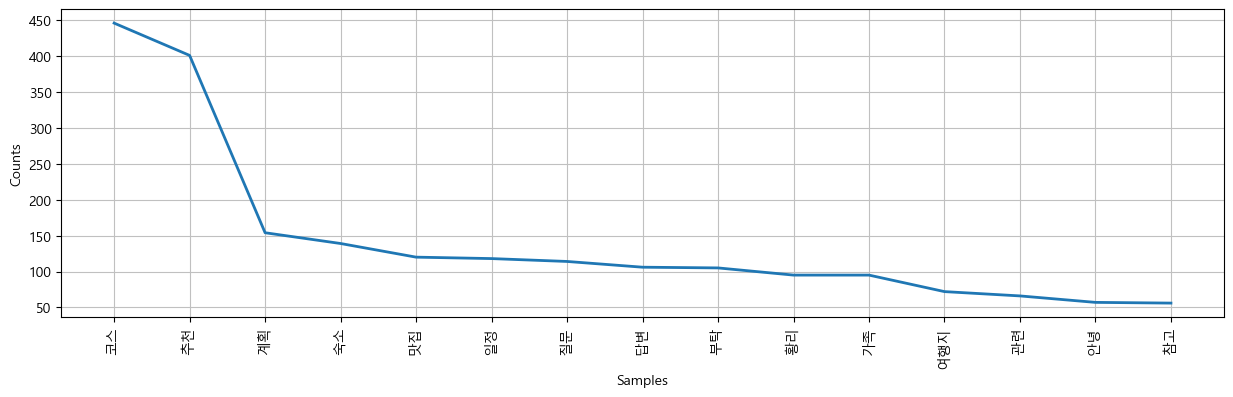

In [38]:
import nltk
data_text = nltk.Text(df_gj_noun)
plt.figure(figsize=(15,4))
plt.rc('font', family='Malgun Gothic')
data_text.plot(15)
plt.show()

In [40]:
data_text.vocab().most_common(15)

[('코스', 446),
 ('추천', 401),
 ('계획', 154),
 ('숙소', 139),
 ('맛집', 120),
 ('일정', 118),
 ('질문', 114),
 ('답변', 106),
 ('부탁', 105),
 ('황리', 95),
 ('가족', 95),
 ('여행지', 72),
 ('관련', 66),
 ('안녕', 57),
 ('참고', 56)]

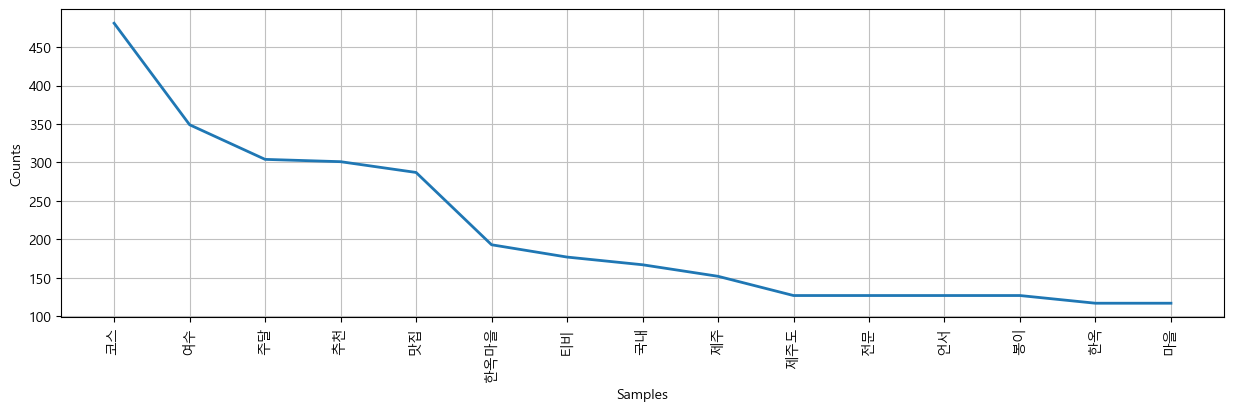

In [42]:
import nltk
data_text2 = nltk.Text(df_jj_noun)
plt.figure(figsize=(15,4))
plt.rc('font', family='Malgun Gothic')
data_text.plot(15)
plt.show()

In [43]:
data_text2.vocab().most_common(15)

[('코스', 481),
 ('여수', 349),
 ('주달', 304),
 ('추천', 301),
 ('맛집', 287),
 ('한옥마을', 193),
 ('티비', 177),
 ('국내', 167),
 ('제주', 152),
 ('제주도', 127),
 ('전문', 127),
 ('언서', 127),
 ('봉이', 127),
 ('한옥', 117),
 ('마을', 117)]

# 5. Word2Vec

In [27]:
import pandas as pd
df = pd.read_csv('data/naver_kin.csv', sep='\t')
df.head()

,keyword,no,title,link,description,total_text
0,전주 여행,1,전주 가볼만한곳 추천 받아요,https://kin.naver.com/qna/detail.naver?d1id=9&...,추억의 7080 다양한체험 7080감성 추억여행 테마박물관 유익한시간 2 전북 전...,전주 가볼만한곳 추천 받아요 추억의 7080 다양한체험 7080감성 추억여행 테마...
1,전주 여행,2,전주여행갈려고하는데요!,https://kin.naver.com/qna/detail.naver?d1id=9&...,전주여행을 갈려고하는데요 아는사람과 갈려고하는데 호텔은 좋은가격에 정했고 음 2박3...,전주여행갈려고하는데요! 전주여행을 갈려고하는데요 아는사람과 갈려고하는데 호텔은 좋은...
2,전주 여행,3,전주 1박 2일 여행 관련 질문~,https://kin.naver.com/qna/detail.naver?d1id=9&...,전주 여행을 계획하고 계시다니 정말 좋은 선택을 하셨네요 전주는 한옥마을과 함께 ...,전주 1박 2일 여행 관련 질문~ 전주 여행을 계획하고 계시다니 정말 좋은 선택을...
3,전주 여행,4,중2 여학생 친구와 전주여행,https://kin.naver.com/qna/detail.naver?d1id=9&...,안녕하세요 중 2 15살 여학생입니다 친한친구와 둘이서 전주 여행을 가기로 했는데 ...,중2 여학생 친구와 전주여행 안녕하세요 중 2 15살 여학생입니다 친한친구와 둘이서...
4,전주 여행,5,부모닝 모시고 전주여행,https://kin.naver.com/qna/detail.naver?d1id=9&...,부모님 모시고 전주여행가려는데 명소 식당 추천부탁드립니다 전주는 한옥마을로 유명한 ...,부모닝 모시고 전주여행 부모님 모시고 전주여행가려는데 명소 식당 추천부탁드립니다 전...


In [5]:
total_text_lst = df['total_text'].to_list()
total_text_lst[:2]

['전주 가볼만한곳 추천 받아요  추억의 7080 다양한체험 7080감성 추억여행 테마박물관 유익한시간 2 전북 전북투어패스 통합이용권 전북핫플 여러여행지 다양한체험 카페이용추가 전주여행필수 편안하고 즐거운 날이 되시길 바라겠습니다 감사합니다 ',
 '전주여행갈려고하는데요! 전주여행을 갈려고하는데요 아는사람과 갈려고하는데 호텔은 좋은가격에 정했고 음 2박3일여행인데 얼마정도갖고가면좋을까요 그리고 맛집같은거 카페같은거 추천해주세요 안녕하세요 전주 여행 계획 중이시네요 한옥마을 근처 ']

In [16]:
from konlpy.tag import Hannanum
han = Hannanum()
total_noun_lst = []
for total_text in total_text_lst:
    noun_list = [word for word, tag in han.pos(total_text, ntags=22) if tag in ('NC', 'NQ')]
    total_noun_lst.append(noun_list)

In [24]:
print(total_noun_lst[-2:])

[['경주여행', '중순', '남편', '경주여행', '계획하', '가보는곳', '황남관한옥호텔', '이튿날', '청공한옥스테이', '2박3', '계획인데요', '여행스케쥴'], ['경주', '여행지', '추천', '부산', '경주', '여행지', '당일치기', '경주', '여행코스', '밑', '자세', '권역별', '여행코스', '소개', '경주여행', '처음', '대릉원', '첨성대', '참고', '쭈니아빠', '블로그', '방문하시', '경주여행']]


In [20]:
from gensim.models import Word2Vec
model = Word2Vec(total_noun_lst, window=10, min_count=2, workers=-1)

In [23]:
model.wv.most_similar('전주')

[('관광', 0.3698463439941406),
 ('적당', 0.2762660086154938),
 ('실제', 0.2752319872379303),
 ('전주국립박물관', 0.2583308517932892),
 ('조선시대', 0.2533281147480011),
 ('캐리어', 0.24960343539714813),
 ('눈', 0.24882428348064423),
 ('휴무일', 0.23413996398448944),
 ('구체적', 0.23368984460830688),
 ('뚜벅이', 0.22961321473121643)]

In [25]:
model.wv.most_similar('경주')

[('관련하', 0.3641005754470825),
 ('레일바이크', 0.3260115385055542),
 ('11월20', 0.3116496205329895),
 ('될거에요', 0.276193767786026),
 ('이용시', 0.26585566997528076),
 ('떡갈비', 0.2404729723930359),
 ('가야되는곳이랑', 0.2382783442735672),
 ('2박3일간', 0.23504950106143951),
 ('중1', 0.22424650192260742),
 ('동네', 0.22275309264659882)]

In [47]:
print('두번 이상 :', list(model.wv.index_to_key[:30]))

두번 이상 : ['여행', '경주', '전주', '경주여행', '전주여행', '추천', '코스', '전주여행코스', '한옥마을', '곳', '맛집', '전주맛집', '전주달봉', '달봉티비', '2박3', '전주가볼만한곳', '여수여행', '국내여행', '숙소', '여수가볼만한곳', '여행코스', '일정', '질문', '주도여행', '안녕', '1박2', '제주도가볼만한곳', '전문', '계획', '인플루언서']


In [50]:
key = input()
if key in model.wv:
    print('{} 단어와 유사한 단어'.format(key))
    print(model.wv.most_similar(key, topn=10))
else:
    print('{} 단어가 훈련데이터에 없음'.format(key))

전주
전주 단어와 유사한 단어
[('관광', 0.3698463439941406), ('적당', 0.2762660086154938), ('실제', 0.2752319872379303), ('전주국립박물관', 0.2583308517932892), ('조선시대', 0.2533281147480011), ('캐리어', 0.24960343539714813), ('눈', 0.24882428348064423), ('휴무일', 0.23413996398448944), ('구체적', 0.23368984460830688), ('뚜벅이', 0.22961321473121643)]
